In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa as lib
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import os

# GPU Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print(f"Using: {device}")

Using: cuda


Noisy Time-Series (29331,)
Clean Time-Series (29331,)


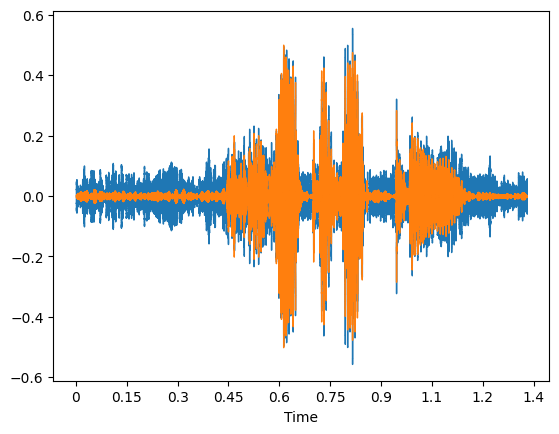

In [3]:

rootPath = r"C:\Users\dell\Downloads\FYP DENOIZER\Voice bank dataset"

clean_training_set = r"C:\Users\dell\Downloads\FYP DENOIZER\Voice bank dataset\clean_trainset_28spk_wav"
noisy_training_set = r"C:\Users\dell\Downloads\FYP DENOIZER\Voice bank dataset\noisy_trainset_28spk_wav"
clean_test_set     = r"C:\Users\dell\Downloads\FYP DENOIZER\Voice bank dataset\clean_testset_wav"
noisy_test_set     = r"C:\Users\dell\Downloads\FYP DENOIZER\Voice bank dataset\noisy_testset_wav"

# os.listdir(noisy_training_set)

# noisy_training_files = np.array([f for f in os.listdir(noisy_training_set)])
# clean_training_files = np.array([f for f in os.listdir(clean_training_set)])

# print(noisy_training_files.dtype)

# print(f"noisy training count {len(noisy_training_files)}")
# print(f"clean training count {len(clean_training_files)}")

yN, srN = lib.load(noisy_training_set+"/p287_386.wav", mono=True, sr=16000)
yC, srC = lib.load(clean_training_set+"/p287_386.wav", mono=True, sr=16000,)
print("Noisy Time-Series",yN.shape)
print("Clean Time-Series",yC.shape)
lib.display.waveshow(yN)
lib.display.waveshow(yC)




#loading all the files to librosa


STFT Parameters & Helper Functions

In [4]:

SAMPLE_RATE = 16000
FFT_SIZE = 512
HOP_LENGTH = 256
WINDOW_TYPE = "hann"
EPSILON = 1e-8


#defining window

def create_window(window_type: str, window_length: int):
    if window_type == "hann":
        return np.hanning(window_length)
    else:
        raise ValueError("Only Hann window is supported for consistency.")


#Frame_waveform
def frame_waveform(waveform, frame_length, hop_length):
    num_frames = 1 + (len(waveform) - frame_length) // hop_length
    frames = np.zeros((num_frames, frame_length))

    for i in range(num_frames):
        start = i * hop_length
        end = start + frame_length
        frames[i] = waveform[start:end]

    return frames


#STFT
def compute_stft(waveform):
    window = create_window(WINDOW_TYPE, FFT_SIZE)

    frames = frame_waveform(
        waveform,
        frame_length=FFT_SIZE,
        hop_length=HOP_LENGTH
    )

    # Apply window
    frames_windowed = frames * window

    # FFT (keep positive frequencies only)
    stft_matrix = np.fft.rfft(frames_windowed, n=FFT_SIZE, axis=1)

    # Transpose to (freq_bins, time_frames)
    stft_matrix = stft_matrix.T

    magnitude = np.abs(stft_matrix)
    phase = np.angle(stft_matrix)

    return magnitude, phase




#logMagnitude
def log_magnitude(magnitude):
    return np.log(magnitude + EPSILON)


def inverse_log_magnitude(log_mag):
    return np.exp(log_mag) - EPSILON



#Padd or crop
def pad_or_crop(spec, target_frames):
    freq_bins, time_frames = spec.shape

    if time_frames < target_frames:
        pad_width = target_frames - time_frames
        padding = np.zeros((freq_bins, pad_width))
        spec = np.concatenate([spec, padding], axis=1)

    elif time_frames > target_frames:
        spec = spec[:, :target_frames]

    return spec


#Preprocessing pipeline


def preprocess_audio(waveform, target_frames):
    magnitude, phase = compute_stft(waveform)

    log_mag = log_magnitude(magnitude)
    log_mag_fixed = pad_or_crop(log_mag, target_frames)

    # Add channel dimension for CNNs: (1, freq_bins, time_frames)
    model_input = log_mag_fixed[np.newaxis, :, :]

    return model_input, phase



#ISTFT Reconstruction
def compute_istft(magnitude, phase):
    window = create_window(WINDOW_TYPE, FFT_SIZE)

    # Recombine magnitude and phase
    complex_spec = magnitude * np.exp(1j * phase)

    # Inverse FFT
    frames = np.fft.irfft(complex_spec, n=FFT_SIZE, axis=0)

    num_frames = frames.shape[1]
    output_length = FFT_SIZE + (num_frames - 1) * HOP_LENGTH
    waveform = np.zeros(output_length)
    window_sum = np.zeros(output_length)

    for i in range(num_frames):
        start = i * HOP_LENGTH
        end = start + FFT_SIZE

        waveform[start:end] += frames[:, i] * window
        window_sum[start:end] += window ** 2

    # Normalize to avoid amplitude distortion
    nonzero_indices = window_sum > EPSILON
    waveform[nonzero_indices] /= window_sum[nonzero_indices]

    return waveform




Initial Validation

In [5]:
mag, phase = compute_stft(yN)

print("Magnitude shape:", mag.shape)
print("Phase shape:", phase.shape)


Magnitude shape: (257, 113)
Phase shape: (257, 113)


In [6]:
log_mag = log_magnitude(mag)

print("Log-mag min:", log_mag.min())
print("Log-mag max:", log_mag.max())


Log-mag min: -15.404319852632428
Log-mag max: 3.0022338544977303


In [7]:
TARGET_FRAMES = 256

model_input, phase = preprocess_audio(yN, TARGET_FRAMES)

print("Model input shape:", model_input.shape)


Model input shape: (1, 257, 256)


In [8]:
reconstructed = compute_istft(mag, phase)

print("Original length:", len(yN))
print("Reconstructed length:", len(reconstructed))


Original length: 29331
Reconstructed length: 29184


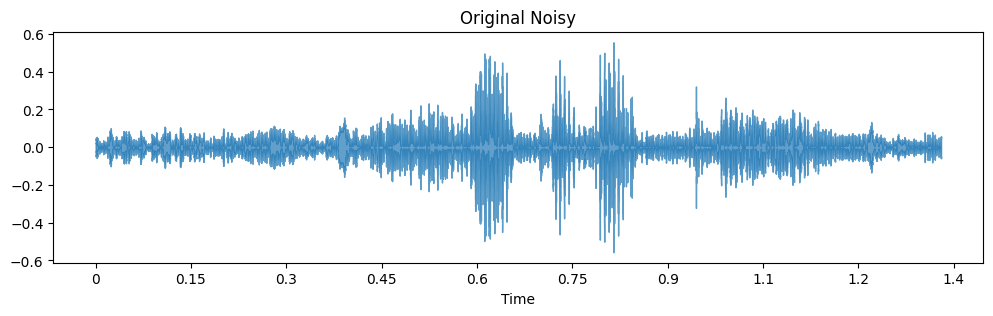

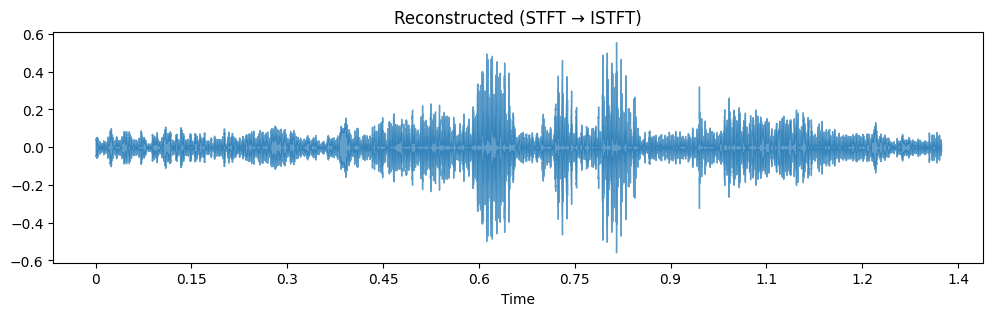

In [9]:
plt.figure(figsize=(12, 3))
lib.display.waveshow(yN, alpha=0.7)
plt.title("Original Noisy")
plt.show()

plt.figure(figsize=(12, 3))
lib.display.waveshow(reconstructed, alpha=0.7)
plt.title("Reconstructed (STFT → ISTFT)")
plt.show()


In [10]:
min_len = min(len(yN), len(reconstructed))
mse = np.mean((yN[:min_len] - reconstructed[:min_len])**2)
print("Reconstruction MSE:", mse)


Reconstruction MSE: 4.490332128956239e-08


Dataset Class


In [11]:
class SpeechEnhancementDataset(Dataset):
    def __init__(self, noisy_dir, clean_dir, target_frames, sample_rate=16000):
        self.target_frames = target_frames
        self.sample_rate = sample_rate
        self.filenames = sorted(os.listdir(noisy_dir))

        print("Preloading dataset into RAM...")
        self.data = []
        for fname in tqdm(self.filenames):
            noisy, _ = lib.load(os.path.join(noisy_dir, fname), sr=sample_rate, mono=True)
            clean, _ = lib.load(os.path.join(clean_dir, fname), sr=sample_rate, mono=True)
            noisy_input, _ = preprocess_audio(noisy, target_frames)
            clean_input, _ = preprocess_audio(clean, target_frames)
            # ← Fixed
            noisy_tensor = torch.tensor(noisy_input).float()
            clean_tensor = torch.tensor(clean_input).float()
            self.data.append((noisy_tensor, clean_tensor))
        print(f" Loaded {len(self.data)} samples into RAM")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [12]:
dataset = SpeechEnhancementDataset(
    noisy_dir=noisy_training_set,
    clean_dir=clean_training_set,
    target_frames=256
)

x, y = dataset[0]

print(x.shape, y.shape)

Preloading dataset into RAM...


  0%|          | 0/11572 [00:00<?, ?it/s]

  1%|          | 87/11572 [00:03<08:22, 22.85it/s]


KeyboardInterrupt: 

In [ ]:
BATCH_SIZE = 16

train_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,    
    drop_last=True
)

print(f"Total batches: {len(train_loader)}")

Total batches: 723


In [19]:
noisy_batch, clean_batch = next(iter(train_loader))

print(noisy_batch.shape)
print(clean_batch.shape)


torch.Size([16, 1, 257, 256])
torch.Size([16, 1, 257, 256])


In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)     

class UNetSpeechEnhancement(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = ConvBlock(1, 16)
        self.enc2 = ConvBlock(16, 32)
        self.enc3 = ConvBlock(32, 64)
        self.enc4 = ConvBlock(64, 128)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ConvBlock(128, 256)

        # Decoder 
          #self.up4 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec4 = ConvBlock(256 + 128, 128)

          #self.up3 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec3 = ConvBlock(128 + 64, 64)

          #self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec2 = ConvBlock(64 + 32, 32)

          #self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec1 = ConvBlock(32 + 16, 16)

        # Output mask
        self.output_conv = nn.Conv2d(16, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
    # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder with skip connections
        d4 = self.dec4(torch.cat([F.interpolate(b,  size=e4.shape[2:], mode='bilinear', align_corners=True), e4], dim=1))
        d3 = self.dec3(torch.cat([F.interpolate(d4, size=e3.shape[2:], mode='bilinear', align_corners=True), e3], dim=1))
        d2 = self.dec2(torch.cat([F.interpolate(d3, size=e2.shape[2:], mode='bilinear', align_corners=True), e2], dim=1))
        d1 = self.dec1(torch.cat([F.interpolate(d2, size=e1.shape[2:], mode='bilinear', align_corners=True), e1], dim=1))

        # FIX 2: Residual learning — predict noise, subtract from input
        # Model learns: enhanced = noisy - predicted_noise
        noise_pred = self.output_conv(d1)   # remove sigmoid — direct regression
        enhanced = x - noise_pred

        return enhanced, noise_pred
        


# Verify model works
model = UNetSpeechEnhancement().to(device)   # ← Fixed: moved to GPU
dummy_input = torch.randn(8, 1, 257, 256).to(device)
enhanced, mask = model(dummy_input)
print(f"Enhanced shape: {enhanced.shape}")
print(f"Mask shape: {mask.shape}")

Enhanced shape: torch.Size([8, 1, 257, 256])
Mask shape: torch.Size([8, 1, 257, 256])


In [21]:
model = UNetSpeechEnhancement().to(device)

dummy_input = torch.randn(8, 1, 257, 256).to(device)
enhanced, mask = model(dummy_input)

print(enhanced.shape)
print(mask.shape)

torch.Size([8, 1, 257, 256])
torch.Size([8, 1, 257, 256])


In [23]:
# Cell 19 — Replace Loss & Optimizer cell
criterion = nn.L1Loss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # ← 10x higher start LR

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=100,        # total epochs
    eta_min=1e-6      # minimum LR
)

In [24]:
noisy_batch, clean_batch = next(iter(train_loader))

# ← Add .float() and move to GPU
noisy_batch = noisy_batch.to(device).float()
clean_batch = clean_batch.to(device).float()

enhanced, mask = model(noisy_batch)

loss = criterion(enhanced, clean_batch)
print(loss.item())

1.5740622282028198


In [ ]:
# Cell 21 — Change epochs
EPOCHS = 100   # ← double the epochs
CHECKPOINT_PATH = "best_checkpoint.pth"
# Also load from best checkpoint to continue from where you left off
checkpoint = torch.load("best_model.pth")
model.load_state_dict(checkpoint)
print("✅ Loaded best model, continuing training...")
best_loss = float('inf')

os.makedirs("checkpoints", exist_ok=True)

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0

    progress_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}]")

    for noisy_batch, clean_batch in progress_bar:
        # ← Fixed: move batches to GPU
        noisy_batch = noisy_batch.to(device).float()
        clean_batch = clean_batch.to(device).float()

        optimizer.zero_grad()

        enhanced, _ = model(noisy_batch)

        loss = criterion(enhanced, clean_batch)
        loss.backward() #backpropagation

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # ← stability
        optimizer.step()

        epoch_loss += loss.item()

        # Live loss update in progress bar
        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = epoch_loss / len(train_loader)
    scheduler.step()

    print(f"Epoch [{epoch+1}/{EPOCHS}] — Avg Loss: {avg_loss:.4f} — LR: {optimizer.param_groups[0]['lr']:.6f}")

    # # Save checkpoint every epoch
    # torch.save({
    #     'epoch': epoch + 1,
    #     'model_state_dict': model.state_dict(),
    #     'optimizer_state_dict': optimizer.state_dict(),
    #     'loss': avg_loss,
    # }, f"checkpoints/checkpoint_epoch_{epoch+1}.pth")

    if avg_loss < best_loss:
        best_loss = avg_loss
        #  FIX 3: Save full checkpoint including optimizer state
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
        }, CHECKPOINT_PATH)
        print(f"  ✅ Best model saved at epoch {epoch+1} — Loss: {best_loss:.4f}")

print("Training complete!")


C:\Users\dell\AppData\Local\Temp\ipykernel_6204\1081162758.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("best_model.pth")


✅ Loaded best model, continuing training...


Epoch [1/100]: 100%|██████████| 723/723 [01:15<00:00,  9.53it/s, loss=0.6694]


Epoch [1/100] — Avg Loss: 1.8514 — LR: 0.000999
  ✅ Best model saved at epoch 1 — Loss: 1.8514


Epoch [2/100]: 100%|██████████| 723/723 [01:13<00:00,  9.78it/s, loss=0.6484]


...

Epoch [68/100]: 100%|██████████| 723/723 [01:15<00:00,  9.57it/s, loss=0.4406]


Epoch [68/100] — Avg Loss: 0.4156 — LR: 0.000220


Epoch [69/100]: 100%|██████████| 723/723 [01:15<00:00,  9.58it/s, loss=0.4207]


Epoch [69/100] — Avg Loss: 0.4153 — LR: 0.000207


Epoch [70/100]:  92%|█████████▏| 662/723 [01:09<00:06,  9.82it/s, loss=0.4175]

In [ ]:
len(train_loader)


1446

In [13]:
import soundfile as sf

# Load a test file
test_noisy, _ = lib.load(
    os.path.join(noisy_test_set, os.listdir(noisy_test_set)[14]),
    sr=16000, mono=True
)

# Get the FULL stft of original audio (for phase)
full_mag, full_phase = compute_stft(test_noisy)
original_frames = full_mag.shape[1]   # actual number of frames

# Preprocess for model (pads/trims to 256)
model_input, _ = preprocess_audio(test_noisy, TARGET_FRAMES)
model_input = torch.tensor(model_input).float().unsqueeze(0).to(device)

# Run through model
model.eval()
with torch.no_grad():
    enhanced, mask = model(model_input)

# Convert back — trim or pad enhanced output to match original phase length
enhanced_np = enhanced.squeeze().cpu().numpy()  # (257, 256)

# ← Fixed: match enhanced magnitude size to original phase size
if original_frames <= TARGET_FRAMES:
    enhanced_mag = enhanced_np[:, :original_frames]   # trim to original
else:
    pad = original_frames - TARGET_FRAMES
    enhanced_mag = np.pad(enhanced_np, ((0,0),(0,pad)), mode='constant')  # pad

# Reverse log magnitude
mag = np.exp(enhanced_mag) - 1e-8

# Reconstruct using original phase
reconstructed = compute_istft(mag, full_phase)

# Save both files
sf.write("noisy_original.wav", test_noisy, 16000)
sf.write("enhanced_output.wav", reconstructed, 16000)
print(f" Saved both files!")
print(f"   Original frames: {original_frames}, Enhanced frames: {enhanced_mag.shape[1]}")

NameError: name 'model' is not defined